# 05 - Return Risk Prediction Classification System
**Project:** Amazon India Sales Analytics & AI-Powered Business Intelligence System  
**Workflow:** Dataset Ingestion -> Filtering -> Feature Preprocessing -> Model Benchmarking -> Best Model Selection -> Risk Inference

---

### Machine Learning Objective:
Predict the likelihood that an incoming e-commerce order will result in a **customer return (`Is_Returned = 1`)**.  
This enables Amazon managers to flag high-risk orders in advance, implement targeted courier checks, verify addresses, or request prepayment.

### Pipeline Steps (Strictly following end-to-end ML methodology):
1. **Take Dataset**: Ingest `data/processed/amazon_sales_cleaned.csv`.
2. **Filtering**: Select orders that reached fulfillment (delivered or returned), excluding pre-dispatch cancellations.
3. **Preprocessing & Feature Engineering**: One-hot encode categorical factors (`Category`, `Product`, `Payment_Method`, `Fulfillment`, `Ship_State`) and include order size/financials (`Quantity`, `Unit_Price_INR`, `Discount_Pct`, `Total_Sales_INR`).
4. **Stratified Train/Test Split**: Maintain exact class ratio in train and test splits to handle the imbalanced return rate (~5%).
5. **Candidate Classifiers Comparison**:
   - Model 1: **Logistic Regression** (with StandardScaler Pipeline & balanced class weights)
   - Model 2: **Decision Tree Classifier** (Max depth constrained)
   - Model 3: **Random Forest Classifier** (Ensemble of trees with balanced weights)
   - Model 4: **XGBoost Classifier** (Gradient boosted trees with positive class weighting `scale_pos_weight`)
6. **Evaluation & Leaderboard**: Compare on Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
7. **Best Model Selection**: Pick the best classifier based on ROC-AUC and F1 performance.
8. **Comprehensive Diagnostics**: Classification report, confusion matrix, ROC curve, and top 15 feature importances.
9. **Artifact Serialization & Real-Time Inference**: Save `models/return_prediction_model.pkl` and test on simulated live order scenarios!


In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

if ".." not in sys.path:
    sys.path.append("..")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Step 1: Take Dataset & Filter
We ingest the processed dataset and define the target variable `Is_Returned`. We filter for fulfilled orders (Delivered and Returned), filtering out early cancellations.


In [2]:
data_path = "../data/processed/amazon_sales_cleaned.csv"
df = pd.read_csv(data_path)

# Filter out orders that were cancelled prior to shipping
df_fulfilled = df[df['Order_Status'] != 'Cancelled'].copy()

# Target variable: 1 if Returned, 0 if Delivered/Shipped
df_fulfilled['Is_Returned'] = (df_fulfilled['Order_Status'] == 'Returned').astype(int)

return_count = df_fulfilled['Is_Returned'].sum()
total_fulfilled = len(df_fulfilled)
print(f"Total Fulfilled Orders: {total_fulfilled:,}")
print(f"Total Returned Orders:  {return_count:,} ({return_count / total_fulfilled * 100:.2f}%)")
print(f"Total Retained Orders:  {total_fulfilled - return_count:,} ({(total_fulfilled - return_count) / total_fulfilled * 100:.2f}%)")


Total Fulfilled Orders: 9,500
Total Returned Orders:  485 (5.11%)
Total Retained Orders:  9,015 (94.89%)


## Step 2: Preprocessing & One-Hot Feature Encoding
Convert categorical features into numeric indicators and extract feature matrices.


In [3]:
cat_features = ['Category', 'Product', 'Payment_Method', 'Fulfillment', 'Ship_State']
num_features = ['Quantity', 'Unit_Price_INR', 'Discount_Pct', 'Total_Sales_INR']

X_raw = df_fulfilled[cat_features + num_features].copy()
y = df_fulfilled['Is_Returned'].copy()

# One-hot encoding
X = pd.get_dummies(X_raw, columns=cat_features, drop_first=True)
feature_names = list(X.columns)

print(f"Encoded Feature Matrix Shape: {X.shape[0]:,} rows, {X.shape[1]} features")
X.head(3)


Encoded Feature Matrix Shape: 9,500 rows, 47 features


,Quantity,Unit_Price_INR,Discount_Pct,Total_Sales_INR,Category_Beauty & Personal Care,Category_Electronics & Mobiles,Category_Home & Kitchen,Category_Pantry & Groceries,Product_Assorted Dry Fruits 500g,Product_Ayurvedic Hair Oil,...,Fulfillment_Seller Flex,Ship_State_Gujarat,Ship_State_Karnataka,Ship_State_Kerala,Ship_State_Maharashtra,Ship_State_Rajasthan,Ship_State_Tamil Nadu,Ship_State_Telangana,Ship_State_Uttar Pradesh,Ship_State_West Bengal
0,3,637.86,0.05,1817.90,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1,1802.51,0.05,1712.38,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1,6095.25,0.05,5790.49,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 3: Stratified Train / Test Split
Given the ~5% positive class ratio, stratified splitting guarantees the same proportion of returns in both train and test partitions.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pos_weight = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)

print(f"Train set: {len(X_train):,} samples (Returns: {sum(y_train):,})")
print(f"Test set:  {len(X_test):,} samples (Returns: {sum(y_test):,})")
print(f"Class imbalance ratio (pos_weight): {pos_weight:.2f}")


Train set: 7,600 samples (Returns: 388)
Test set:  1,900 samples (Returns: 97)
Class imbalance ratio (pos_weight): 18.59


## Step 4: Candidate Models Comparison
We evaluate four standard classification algorithms configured with cost-sensitive class weights:
1. **Logistic Regression** (Standardized)
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **XGBoost Classifier**


In [5]:
classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, class_weight="balanced", random_state=42),
    "XGBoost Classifier": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, scale_pos_weight=pos_weight, random_state=42, eval_metric="logloss")
}

comparison_results = []
trained_models = {}
test_probabilities = {}
test_predictions = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else preds

    trained_models[name] = clf
    test_predictions[name] = preds
    test_probabilities[name] = probs

    comparison_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4)
    })

leaderboard_clf = pd.DataFrame(comparison_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("=== Classification Model Comparison Leaderboard ===")
leaderboard_clf


=== Classification Model Comparison Leaderboard ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8153,0.0738,0.2268,0.1114,0.5348
1,XGBoost Classifier,0.6300,0.0478,0.3299,0.0834,0.4876
2,Logistic Regression,0.5326,0.0490,0.4433,0.0883,0.4843
3,Decision Tree,0.3047,0.0500,0.7010,0.0933,0.4770


## Step 5: Best Model Selection & In-Depth Diagnostics
Selecting the top performer and examining its Confusion Matrix, ROC-AUC Curve, and Classification Report.


In [6]:
best_clf_name = leaderboard_clf.iloc[0]['Model']
best_clf = trained_models[best_clf_name]
best_probs = test_probabilities[best_clf_name]
best_preds = test_predictions[best_clf_name]

print(f"Selected Best Classifier: {best_clf_name}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, best_preds, target_names=['Retained (0)', 'Returned (1)']))


Selected Best Classifier: Random Forest

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Retained (0)       0.95      0.85      0.90      1803
Returned (1)       0.07      0.23      0.11        97

    accuracy                           0.82      1900
   macro avg       0.51      0.54      0.50      1900
weighted avg       0.91      0.82      0.86      1900



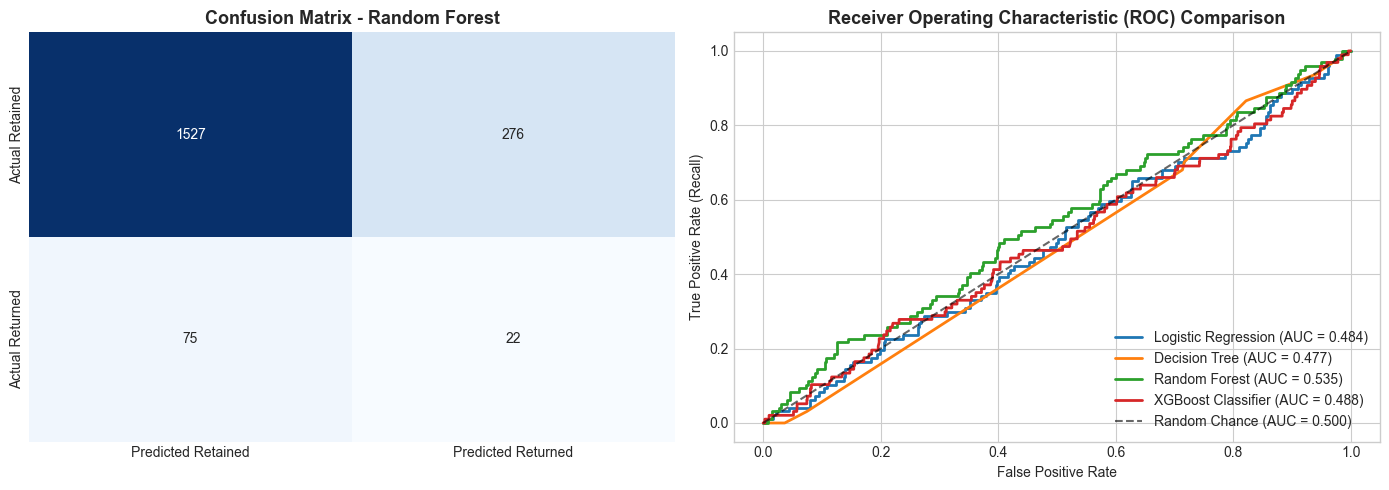

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Retained', 'Predicted Returned'],
            yticklabels=['Actual Retained', 'Actual Returned'])
axes[0].set_title(f'Confusion Matrix - {best_clf_name}', fontsize=13, fontweight='bold')

# ROC Curves Comparison
for name, probs in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Chance (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Comparison', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## Step 6: Feature Importance Analysis
Which factors contribute most to return risk?


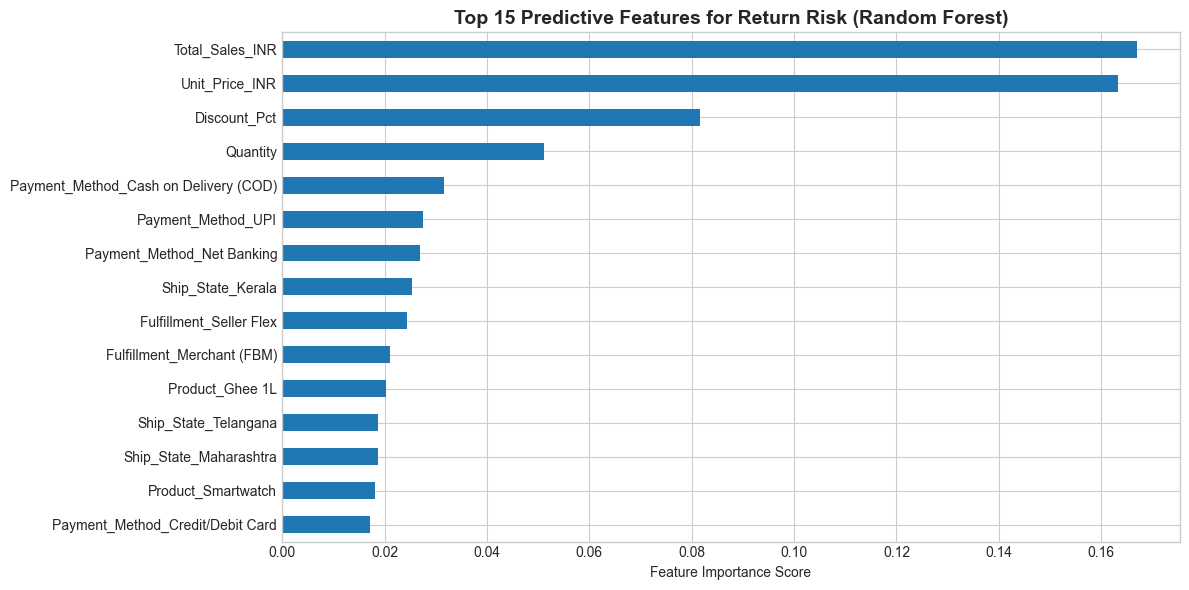

In [8]:
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    feat_imp.plot(kind='barh', color='#1f77b4').invert_yaxis()
    plt.title(f'Top 15 Predictive Features for Return Risk ({best_clf_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Importance Score')
    plt.tight_layout()
    plt.show()


## Step 7: Save Model Artifact & Live Inference Simulator
Refit the chosen model on the complete dataset and save the artifact to `models/return_prediction_model.pkl`.


In [9]:
import sys
if ".." not in sys.path:
    sys.path.append("..")
from src.prediction import train_and_save_best_classifier, predict_order_return_risk

# Save best model artifact
artifact = train_and_save_best_classifier(df)

# Test real-time inference on sample orders
sample_order_low = {
    'Category': 'Pantry & Groceries',
    'Product': 'Ghee 1L',
    'Quantity': 2,
    'Unit_Price_INR': 450.0,
    'Discount_Pct': 0.05,
    'Payment_Method': 'UPI',
    'Fulfillment': 'Amazon (FBA)',
    'Ship_State': 'Maharashtra'
}

sample_order_high = {
    'Category': 'Electronics & Mobiles',
    'Product': '5G Smartphone',
    'Quantity': 3,
    'Unit_Price_INR': 32000.0,
    'Discount_Pct': 0.20,
    'Payment_Method': 'Cash on Delivery (COD)',
    'Fulfillment': 'Merchant (FBM)',
    'Ship_State': 'Uttar Pradesh'
}

print("=== Simulated Order 1 (Grocery item via UPI) ===")
print(predict_order_return_risk(sample_order_low, artifact))

print("\n=== Simulated Order 2 (High-value smartphone via COD) ===")
print(predict_order_return_risk(sample_order_high, artifact))


=== Return Risk Classification Leaderboard ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 XGBoost Classifier    0.6335     0.0546  0.4021    0.0962   0.5248
Logistic Regression    0.5300     0.0521  0.5052    0.0944   0.5213
      Random Forest    0.8395     0.0484  0.1237    0.0696   0.5125
      Decision Tree    0.7430     0.0477  0.2268    0.0789   0.4927

Best Classifier Selected: XGBoost Classifier
Saved best return prediction model (XGBoost Classifier) to: models/return_prediction_model.pkl
=== Simulated Order 1 (Grocery item via UPI) ===
{'return_probability': 43.51, 'risk_level': 'Medium Risk', 'badge_color': 'orange', 'recommendation': 'Moderate risk. Standard delivery with delivery notification SMS is advised.'}

=== Simulated Order 2 (High-value smartphone via COD) ===
{'return_probability': 26.44, 'risk_level': 'Low Risk', 'badge_color': 'green', 'recommendation': 'Low return likelihood. Fast-track order for fulfillment.'}
